# Part 3 — Testing the gamble

Two camps made testable claims about what drives private investment.

- **LABOUR/ILO** said investment follows **demand**, so lagged GDP growth should
  carry a positive coefficient.
- **SAF/GEAR** said investment follows **confidence**, signalled by fiscal
  consolidation, so the deficit should carry a negative one.

We regress real private investment growth on lagged GDP growth, the real interest
rate, and the deficit, from 1994 to 2024.

**Sign convention:** the deficit is positive when the budget is in deficit.

## Setup

In [ ]:
from pathlib import Path
import pandas as pd

# Find the project folder: walk up from the working directory until we see a
# folder holding both resources/ and output/. This works whether the notebook is
# run from its own folder or from the repository root, so it keeps working after
# the project is moved or cloned onto another machine.
def find_project(start=None):
    here = Path(start or Path.cwd()).resolve()
    for folder in [here, *here.parents]:
        if (folder / "resources").is_dir() and (folder / "output").is_dir():
            return folder
    raise FileNotFoundError(
        "Could not find the project folder (the one containing 'resources' and "
        "'output'). Open this notebook from inside the project folder."
    )


PROJECT = find_project()

RES = PROJECT / "resources"                  # supplied data, never written to
BASE = PROJECT / "output"                    # everything we generate

print("Project folder:", PROJECT)

import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from statsmodels.stats.diagnostic import acorr_breusch_godfrey, het_breuschpagan
from statsmodels.stats.stattools import durbin_watson, jarque_bera
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy import stats as sps

ADDITIONAL_DIR = RES / "data" / "Additional data"
FORMULA = "inv_growth ~ gdp_growth_lag1 + real_rate + deficit_gdp"

## Build the dataset

Part 2 deliberately chains data vintages so GEAR can be judged against the data of
its own day. That would be wrong here: a definition that changes mid-sample gets
baked into the coefficients. So we use one consistent current vintage throughout,
and keep the older Boshoff & Fourie series as a sensitivity check.

In [2]:
# Dependent variable: real private investment growth.
inv = pd.read_csv(ADDITIONAL_DIR / "sarb_private_investment_1994_2025_RAW.csv")
inv = inv[["year", "growth_pct"]].rename(columns={"growth_pct": "inv_growth"})

# Real GDP growth, current vintage (SARB) and the older factor-cost series.
gdp = pd.read_csv(ADDITIONAL_DIR / "sarb_gdp_marketprices_1999_2025_RAW.csv")
gdp = gdp[["year", "sarb_growth_pct"]].rename(columns={"sarb_growth_pct": "gdp_growth_sarb"})

bf = pd.read_csv(RES / "data" / "sa_gdp_1911_2017.csv")
bf = bf[["year", "real_gdp_growth_pct"]].rename(columns={"real_gdp_growth_pct": "gdp_growth_bf"})

# Real interest rate.
rate = pd.read_csv(ADDITIONAL_DIR / "real_policy_rate_1994_2025.csv")
rate = rate[["year", "real_policy_rate_pct"]].rename(columns={"real_policy_rate_pct": "real_rate"})

# Deficit: shift to calendar years and flip the sign so a deficit is positive.
def_ = pd.read_csv(ADDITIONAL_DIR / "deficit_pct_gdp_1994_2025_FINAL.csv")
def_["year"] = def_["fiscal_year_ending_march"] - 1
def_["deficit_gdp"] = -def_["deficit_pct_gdp"]
def_ = def_[["year", "deficit_gdp"]]

df = (inv.merge(gdp, on="year", how="outer")
         .merge(bf, on="year", how="outer")
         .merge(rate, on="year", how="outer")
         .merge(def_, on="year", how="outer")
         .sort_values("year").reset_index(drop=True))

# Prefer the current vintage; fall back to Boshoff & Fourie before SARB starts.
df["gdp_growth"] = df["gdp_growth_sarb"].fillna(df["gdp_growth_bf"])

# Record which GDP series each year came from.
df["gdp_growth_source"] = df["gdp_growth_sarb"].notna().map(
    {True: "SARB market prices", False: "Boshoff & Fourie factor cost"})
df.loc[df["gdp_growth"].isna(), "gdp_growth_source"] = None

# Investment responds to LAST year's demand, so lag the growth terms.
df["gdp_growth_lag1"] = df["gdp_growth"].shift(1)
df["gdp_growth_bf_lag1"] = df["gdp_growth_bf"].shift(1)

df.to_csv(BASE / "data" / "part3_regression_data.csv", index=False)

sample = df.dropna(subset=["inv_growth", "gdp_growth_lag1", "real_rate", "deficit_gdp"])
print(f"Estimation sample: {int(sample.year.min())}-{int(sample.year.max())}, N = {len(sample)}")
sample[["year", "inv_growth", "gdp_growth_lag1", "real_rate", "deficit_gdp"]].head()

Estimation sample: 1994-2024, N = 31


,year,inv_growth,gdp_growth_lag1,real_rate,deficit_gdp
83,1994,12.710000,0.41,4.00,3.99
84,1995,10.914943,2.58,5.80,3.76
85,1996,7.692678,3.07,8.52,4.00
86,1997,4.829081,4.59,8.15,2.85
87,1998,-1.926040,2.28,11.85,2.18


## Estimate

Annual macro data has autocorrelated errors, so we report Newey-West standard
errors rather than plain OLS ones, which would overstate how precise the estimates
are.

In [3]:
def fit(data, formula=FORMULA):
    """Fit the model with Newey-West standard errors. Returns (sample, ols, hac)."""
    s = data.dropna(subset=["inv_growth", "gdp_growth_lag1", "real_rate", "deficit_gdp"])
    model = smf.ols(formula, data=s)
    return s, model.fit(), model.fit(cov_type="HAC", cov_kwds={"maxlags": 1})


def show(res, label):
    """Print coefficients in a compact table."""
    print(f"\n{label}   N = {int(res.nobs)}   R2 = {res.rsquared:.3f}")
    print(f"{'variable':<20}{'coef':>9}{'s.e.':>9}{'p':>9}")
    for name in res.params.index:
        star = " *" if res.pvalues[name] < 0.05 else ""
        print(f"{name:<20}{res.params[name]:>9.3f}{res.bse[name]:>9.3f}"
              f"{res.pvalues[name]:>9.3f}{star}")


sample, ols_main, hac_main = fit(df)
show(hac_main, "FULL SAMPLE 1994-2024")


FULL SAMPLE 1994-2024   N = 31   R2 = 0.422
variable                 coef     s.e.        p
Intercept               8.264    2.701    0.002 *
gdp_growth_lag1         0.521    0.389    0.180
real_rate              -0.062    0.372    0.868
deficit_gdp            -1.831    0.596    0.002 *


Read that row on its own and GEAR wins. The deficit coefficient is negative and
significant, exactly what the confidence argument predicts, while lagged GDP
growth is not significant.

Two checks show it should not be read on its own.

## Diagnostics

In [4]:
# Standard residual checks.
print(f"Durbin-Watson      {durbin_watson(ols_main.resid):.3f}   (2 = no autocorrelation)")

bg = acorr_breusch_godfrey(ols_main, nlags=1)
print(f"Breusch-Godfrey    LM {bg[0]:.2f}, p {bg[1]:.3f}  -> "
      f"{'autocorrelation, so use HAC errors' if bg[1] < 0.05 else 'no autocorrelation'}")

bp = het_breuschpagan(ols_main.resid, ols_main.model.exog)
print(f"Breusch-Pagan      LM {bp[0]:.2f}, p {bp[1]:.3f}  -> "
      f"{'heteroskedastic' if bp[1] < 0.05 else 'no heteroskedasticity'}")

jb = jarque_bera(ols_main.resid)
print(f"Jarque-Bera        JB {jb[0]:.2f}, p {jb[1]:.3f}  -> "
      f"{'non-normal' if jb[1] < 0.05 else 'normality not rejected'}")

# Multicollinearity: anything above 10 would be a problem.
X = sample[["gdp_growth_lag1", "real_rate", "deficit_gdp"]].copy()
X.insert(0, "const", 1.0)
print("\nVIFs:")
for i, name in enumerate(X.columns):
    if name != "const":
        print(f"  {name:<20}{variance_inflation_factor(X.values, i):.2f}")

Durbin-Watson      1.184   (2 = no autocorrelation)
Breusch-Godfrey    LM 5.01, p 0.025  -> autocorrelation, so use HAC errors
Breusch-Pagan      LM 3.75, p 0.290  -> no heteroskedasticity
Jarque-Bera        JB 0.08, p 0.960  -> normality not rejected

VIFs:
  gdp_growth_lag1     1.32
  real_rate           1.16
  deficit_gdp         1.50


## Check 1 — split the sample at 2008

A Chow test asks whether the same relationship holds before and after 2008.

In [ ]:
# Chow test for a break at 2008.
pre, post = sample[sample.year < 2008], sample[sample.year >= 2008]
rss_all = smf.ols(FORMULA, data=sample).fit().ssr
rss_pre = smf.ols(FORMULA, data=pre).fit().ssr
rss_post = smf.ols(FORMULA, data=post).fit().ssr

k, n = 4, len(sample)
F = ((rss_all - (rss_pre + rss_post)) / k) / ((rss_pre + rss_post) / (n - 2 * k))
p = 1 - sps.f.cdf(F, k, n - 2 * k)
print(f"Chow F({k}, {n - 2*k}) = {F:.2f}, p = {p:.3f}"
      f"  -> {'structural break' if p < 0.05 else 'no break'}")

_, _, hac_pre = fit(df[df.year < 2008])
_, _, hac_post = fit(df[df.year >= 2008])
show(hac_pre, "PRE-2008")
show(hac_post, "2008 ONWARDS")

The deficit coefficient does not just weaken. It **flips sign** and is significant
in both directions: positive before 2008, negative after. A coefficient that
reverses like that is not measuring a stable behavioural parameter. The
full-sample number is averaging two opposite regimes.

## Check 2 — drop the two recession years

In 2009 and 2020 the deficit exploded and investment collapsed, but the recession
caused both. Automatic stabilisers widen the deficit in a downturn by
construction, so the correlation runs recession to deficit, not deficit to lost
confidence.

This is the endogeneity problem made concrete. Dropping two years out of 31 is a
diagnostic, not a preferred estimate.

In [5]:
# Remove the two crisis years and refit.
_, _, hac_nocrisis = fit(df[~df.year.isin([2009, 2020])])
_, _, hac_post_nc = fit(df[(df.year >= 2008) & (~df.year.isin([2009, 2020]))])

show(hac_nocrisis, "FULL SAMPLE, EXCLUDING 2009 AND 2020")
show(hac_post_nc, "2008 ONWARDS, EXCLUDING 2009 AND 2020")


FULL SAMPLE, EXCLUDING 2009 AND 2020   N = 29   R2 = 0.333
variable                 coef     s.e.        p
Intercept               4.490    2.393    0.061
gdp_growth_lag1         0.941    0.324    0.004 *
real_rate              -0.027    0.329    0.933
deficit_gdp            -0.697    0.483    0.150

2008 ONWARDS, EXCLUDING 2009 AND 2020   N = 15   R2 = 0.575
variable                 coef     s.e.        p
Intercept               2.076    2.950    0.482
gdp_growth_lag1         0.747    0.144    0.000 *
real_rate              -0.984    0.318    0.002 *
deficit_gdp            -0.143    0.656    0.827


Removing two observations reverses the conclusion. The deficit loses significance
entirely, while lagged GDP growth becomes strongly significant and economically
large: a one-point rise in last year's growth goes with roughly a one-point rise
in investment growth.

## Sensitivity — does the answer depend on which GDP series we use?

Honest reporting means showing the specification that undermines our result, not
just the one that supports it.

In [6]:
# Refit using the older Boshoff & Fourie factor-cost GDP series.
alt = df.dropna(subset=["inv_growth", "gdp_growth_bf_lag1", "real_rate", "deficit_gdp"])
alt_model = smf.ols("inv_growth ~ gdp_growth_bf_lag1 + real_rate + deficit_gdp", data=alt)
show(alt_model.fit(cov_type="HAC", cov_kwds={"maxlags": 1}),
     "BOSHOFF & FOURIE GDP VINTAGE (ends 2018)")


BOSHOFF & FOURIE GDP VINTAGE (ends 2018)   N = 25   R2 = 0.251
variable                 coef     s.e.        p
Intercept               8.121    4.971    0.102
gdp_growth_bf_lag1      0.264    0.919    0.774
real_rate               0.050    0.404    0.901
deficit_gdp            -1.705    1.130    0.131


On this vintage nothing is significant. The demand result holds on SARB
market-price GDP and vanishes on the factor-cost series. Part of that is the
shorter sample and part is the change in definition, and the two cannot be
cleanly separated.

## The 1994 split cannot be run

The assignment also asks for a split at 1994. The deficit and interest-rate series
both start in 1994, so there are no earlier observations for two of the three
regressors. This is a limit of the data, not a modelling choice.

In [7]:
# Confirm there is nothing before 1994 to split on.
before_1994 = sample[sample.year < 1994]
print(f"Observations before 1994: {len(before_1994)}")
print(f"Earliest year available:  {int(sample.year.min())}")

Observations before 1994: 0
Earliest year available:  1994


## Plot how the coefficients move across specifications

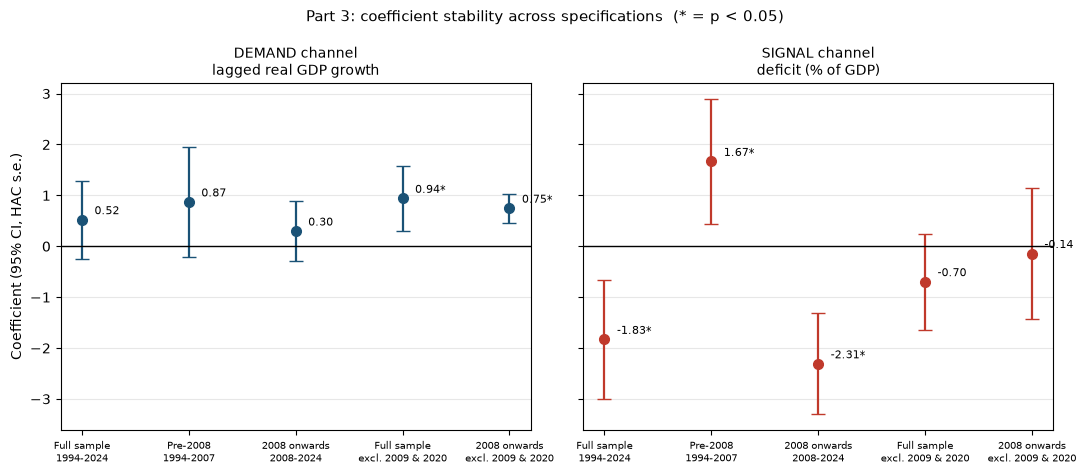

In [8]:
# Compare the two contested coefficients across every specification we ran.
SPECS = [
    ("Full sample\n1994-2024", df),
    ("Pre-2008\n1994-2007", df[df.year < 2008]),
    ("2008 onwards\n2008-2024", df[df.year >= 2008]),
    ("Full sample\nexcl. 2009 & 2020", df[~df.year.isin([2009, 2020])]),
    ("2008 onwards\nexcl. 2009 & 2020", df[(df.year >= 2008) & (~df.year.isin([2009, 2020]))]),
]

results = []
for label, data in SPECS:
    _, _, r = fit(data)
    for var in ["gdp_growth_lag1", "deficit_gdp"]:
        results.append({"spec": label, "var": var, "coef": r.params[var],
                        "se": r.bse[var], "p": r.pvalues[var]})
res_df = pd.DataFrame(results)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.8), sharey=True)
titles = {"gdp_growth_lag1": "DEMAND channel\nlagged real GDP growth",
          "deficit_gdp": "SIGNAL channel\ndeficit (% of GDP)"}
colours = {"gdp_growth_lag1": "#1a5276", "deficit_gdp": "#c0392b"}

for ax, var in zip(axes, ["gdp_growth_lag1", "deficit_gdp"]):
    sub = res_df[res_df["var"] == var].reset_index(drop=True)
    ax.errorbar(range(len(sub)), sub["coef"], yerr=1.96 * sub["se"], fmt="o",
                capsize=5, color=colours[var], markersize=7, linewidth=1.6)
    ax.axhline(0, color="black", linewidth=1)
    for i, r in sub.iterrows():
        ax.annotate(f"{r['coef']:.2f}{'*' if r['p'] < 0.05 else ''}", (i, r["coef"]),
                    textcoords="offset points", xytext=(9, 4), fontsize=8)
    ax.set_xticks(range(len(sub)))
    ax.set_xticklabels(sub["spec"], fontsize=7.5)
    ax.set_title(titles[var], fontsize=10)
    ax.grid(alpha=0.3, axis="y")

axes[0].set_ylabel("Coefficient (95% CI, HAC s.e.)")
fig.suptitle("Part 3: coefficient stability across specifications  (* = p < 0.05)",
             fontsize=11)
fig.tight_layout()
fig.savefig(BASE / "figures" / "part3_coefficient_stability.png", dpi=150)
plt.show()